# 6. Topology and growth

Two things added in the phase-2 review pass that don't fit the earlier notebooks:

1. **A topological description of a cell's branching** -- `BLO_tree`,
   `barcode_tree`, `persistenceimage_tree`, `realisations_tree` -- built on
   persistent homology, and independent of how the cell is rotated or
   embedded in space.
2. **Growing into a volume** -- `growth_tree`, `random_tree`, plus the
   `span_tree`/`theta_tree` space-filling measures a growth can be checked
   against.

Nothing here needs a simulator; everything is geometry and topology.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
from IPython.display import Image

import pynetrees as pt

tree = pt.hsn_tree()
print(tree, f"| {pt.len_tree(tree).sum():.0f} um of cable, "
            f"{int(pt.B_tree(tree).sum())} branch points")

Tree(name='hsn', n_nodes=1290, regions=[soma, axon, dendrite]) | 6320 um of cable, 223 branch points


## Branch length order

`BLO_tree` decomposes the arbor into paths ("branches" in the persistent-homology
sense, not branch *points*): repeatedly take the deepest remaining root-to-tip
path, remove it, repeat. Branch 1 always contains the root.

The default (`by="nodes"`) reproduces MATLAB's `BLO_tree` exactly, warts
included -- see the function's docstring for why that is *not* the same as
"longest first" despite the name. `by="length"` does what the name says.

224 branches, from 319 um (branch 1) down to 4.7 um


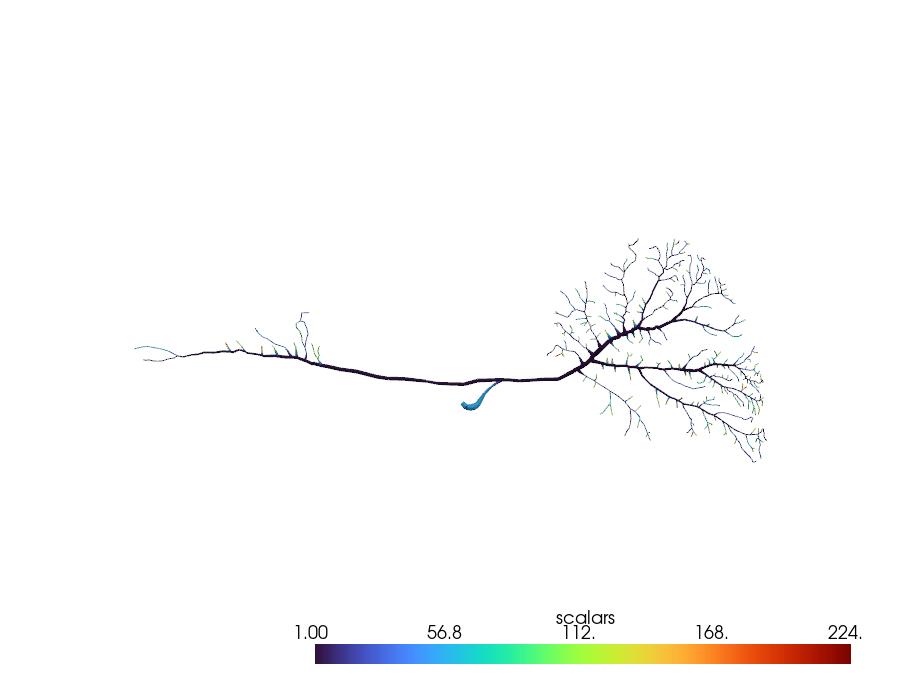

In [2]:
order, length, cumulative = pt.BLO_tree(tree)
print(f"{order.max()} branches, from {length[order == 1][0]:.0f} um "
      f"(branch 1) down to {length[order == order.max()][0]:.1f} um")

pl = pv.Plotter(off_screen=True, window_size=(900, 700))
pt.plot_tree(tree, color=order.astype(float), cmap="turbo", categories=True,
             plotter=pl)
pl.camera_position = "xy"
pl.screenshot("tut06_blo.png")
pl.close()
Image("tut06_blo.png")

## Barcode and persistence image

`barcode_tree` turns the decomposition into `(birth, death)` pairs, one per
branch -- the standard persistence-diagram representation. Because it
describes *branching*, not embedding, it is invariant to rotating the cell.

`persistenceimage_tree` smears the barcode into a fixed-size density image, so
cells of different topology can be compared or clustered pixel by pixel --
which a variable-length list of bars cannot.

224 bars; rotation-invariant: True


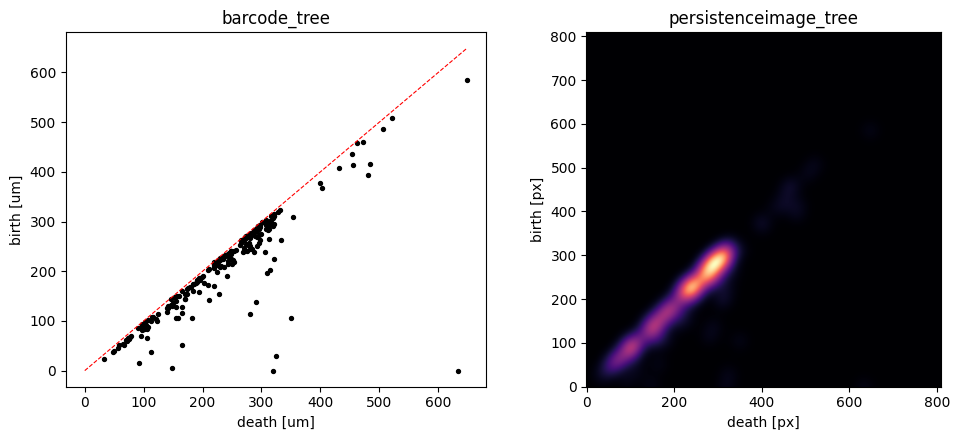

In [3]:
bars = pt.barcode_tree(tree)
rotated_bars = pt.barcode_tree(pt.rot_tree(tree, (30.0, 40.0, 50.0)))
print(f"{len(bars)} bars; rotation-invariant: "
      f"{np.allclose(bars, rotated_bars, atol=1e-6)}")

image = pt.persistenceimage_tree(tree)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))
ax1.scatter(bars[:, 1], bars[:, 0], s=8, c="k")
ax1.plot([0, bars[:, 1].max()], [0, bars[:, 1].max()], "r--", lw=0.8)
ax1.set_xlabel("death [um]"); ax1.set_ylabel("birth [um]")
ax1.set_title("barcode_tree")

ax2.imshow(image, origin="lower", cmap="magma")
ax2.set_xlabel("death [px]"); ax2.set_ylabel("birth [px]")
ax2.set_title("persistenceimage_tree")
fig.tight_layout()
fig.savefig("tut06_barcode.png", dpi=110)

## Realisations: how much the barcode leaves out

A barcode says which branches exist and where each begins and ends, but not
*which* branch each one grew from. `realisations_tree` counts the trees that
share this cell's barcode -- an exact integer, however large, since Python's
integers don't overflow the way MATLAB's doubles do.

In [4]:
exact = pt.realisations_tree(tree)
print(f"{len(str(exact))}-digit number of trees indistinguishable from "
      f"this one by their barcode alone")
print(f"as a double (MATLAB's precision): {float(exact):.6e}")

271-digit number of trees indistinguishable from this one by their barcode alone
as a double (MATLAB's precision): 6.554020e+270


## Space filling: span_tree and theta_tree

`span_tree` rasterises the arbor onto a 1 um grid and closes the gaps between
neighbouring branches, giving the *territory* the cell covers. `theta_tree`
is the radius at which discs centred on every node first cover 90.69% of
that territory (the hexagonal packing fraction) -- small means the arbor
fills its territory finely, large means it leaves gaps.

spans 100,829 um^2 on a 1765x1765 grid; theta = 16.0 um


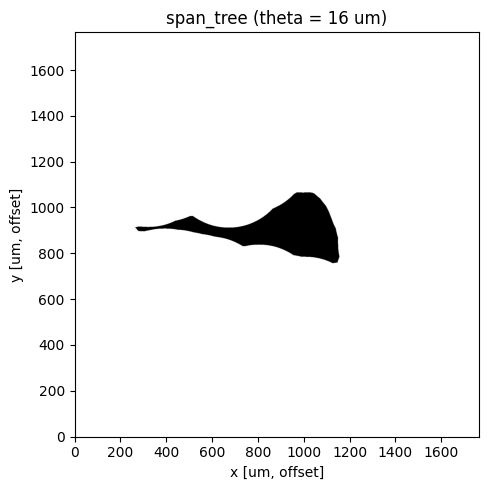

In [5]:
span = pt.span_tree(tree)
theta = pt.theta_tree(tree)
print(f"spans {span.area:,.0f} um^2 on a {span.mask.shape[0]}x"
      f"{span.mask.shape[1]} grid; theta = {theta:.1f} um")

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(span.mask, origin="lower", cmap="gray_r")
ax.set_title(f"span_tree (theta = {theta:.0f} um)")
ax.set_xlabel("x [um, offset]"); ax.set_ylabel("y [um, offset]")
fig.tight_layout()
fig.savefig("tut06_span.png", dpi=110)

## Growing into a volume

`growth_tree` is not `MST_tree` over a fixed point cloud -- it grows into a
*region*, trading three things off at every step: wiring cost (`bf`, as in
`MST_tree`), how far a candidate lies from cable already laid down (`sp`,
which pushes growth into empty territory), and chance (`k`).

Here it grows into `hsn_tree`'s own territory, so the result is a synthetic
cell shaped like the real one without being a copy of it.

581 nodes, 580 um, 150 growth steps


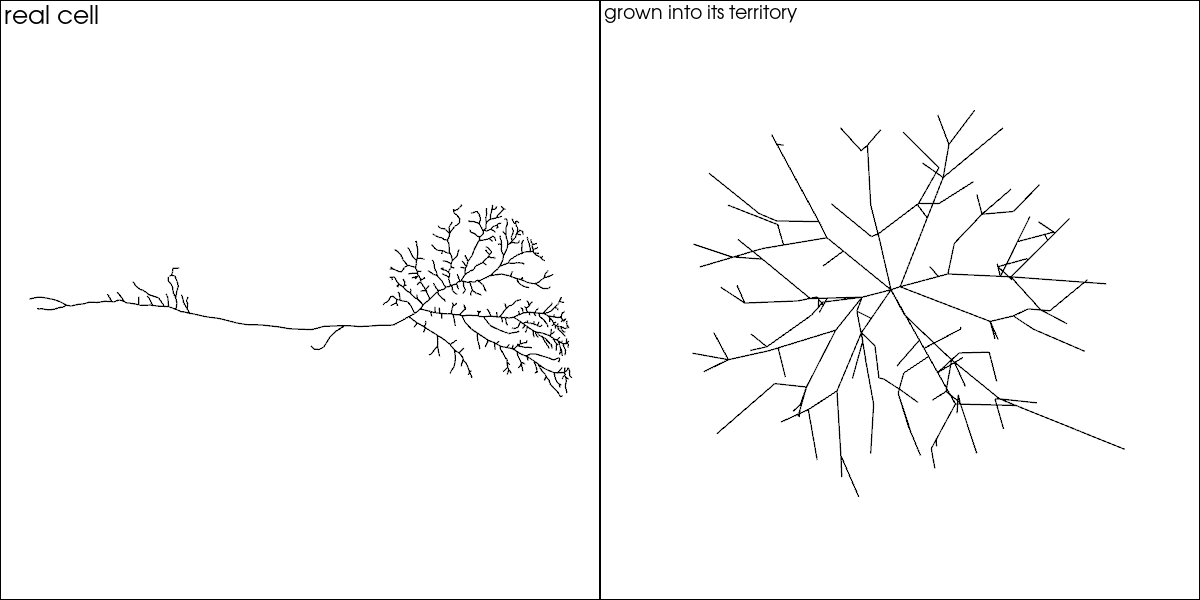

In [6]:
grown = pt.growth_tree(tree, thr=150, sp=0.5,
                        n_target_points=30_000, rng=np.random.default_rng(0))
print(f"{grown.tree.n_nodes} nodes, {grown.tree.total_length:.0f} um, "
      f"{len(grown.length) - 1} growth steps")

pl = pv.Plotter(shape=(1, 2), off_screen=True, window_size=(1200, 600))
pl.subplot(0, 0)
pt.plot_tree(tree, color="black", mode="line", plotter=pl)
pl.add_text("real cell", font_size=11)
pl.camera_position = "xy"
pl.subplot(0, 1)
pt.plot_tree(grown.tree, color="black", mode="line", plotter=pl)
pl.add_text("grown into its territory", font_size=11)
pl.camera_position = "xy"
pl.screenshot("tut06_growth.png")
pl.close()
Image("tut06_growth.png")

### The space-filling factor, and a plain toy tree

`sp` is the parameter that matters most: `0` reduces `growth_tree` to an
ordinary minimum spanning tree over whatever has been reached so far, and
higher values prefer targets far from any existing cable. `random_tree` is
the simplest possible case -- no target territory at all, just `MST_tree`
over a scattered cloud.

random_tree: 150 nodes, 3086 um


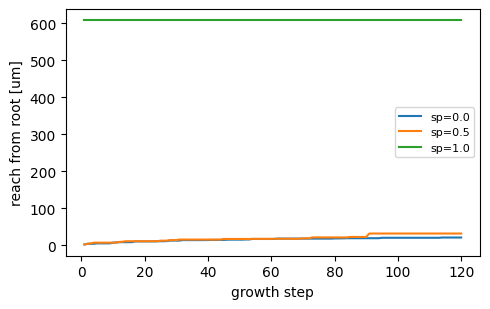

In [7]:
# reach vs. *step*, not cable length: sp=1 reaches for the single furthest
# target on step one, a huge connection that would otherwise dominate a
# length axis and squash the other two curves to a sliver
fig, ax = plt.subplots(figsize=(5, 3.2))
for sp in (0.0, 0.5, 1.0):
    g = pt.growth_tree(tree, thr=120, sp=sp, n_target_points=20_000,
                        history=True, rng=np.random.default_rng(0))
    reach = [pt.eucl_tree(step).max() for step in g.history]
    ax.plot(range(1, len(reach) + 1), reach, label=f"sp={sp}")
ax.set_xlabel("growth step"); ax.set_ylabel("reach from root [um]")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig("tut06_sp_effect.png", dpi=110)

toy = pt.random_tree(150, radius=80.0, rng=np.random.default_rng(0))
print(f"random_tree: {toy.n_nodes} nodes, {toy.total_length:.0f} um")

`sp=1` is a degenerate case worth noticing rather than smoothing over: with no
cable laid down yet, the point furthest from *any* existing cable is simply the
most distant target in the whole cloud, so step one jumps straight there and
`reach` never has anywhere higher to go. `sp=0` and `sp=0.5` grow locally step
by step instead, which is why they stay near the bottom of the same plot for
120 steps -- they are exploring a much larger territory before reaching this
far, not failing to reach it.

**Next:** [`07_generative_pipeline.ipynb`](07_generative_pipeline.ipynb) —
synthesising new trees from a group's statistics, rather than growing one
tree into a fixed volume.